# Image-to-Image: DCGAN
## Generación de imágenes sintéticas de tumores cerebrales

**DCGAN (Deep Convolutional Generative Adversarial Network)** entrena dos redes en competición:
- **Generador (G):** aprende a crear imágenes falsas a partir de ruido aleatorio
- **Discriminador (D):** aprende a distinguir imágenes reales de las generadas

Se entrena **una DCGAN por clase** para generar imágenes sintéticas de cada tipo de tumor.

---
**Índice:**
1. Setup
2. Dataset por clase
3. Arquitectura DCGAN
4. Entrenamiento por clase
5. Resultados y comparativa real vs generado
6. Conclusiones

## 1 · Setup

In [ ]:
import os
from google.colab import drive

# First, attempt to unmount if it's currently mounted.
# This is crucial because force_remount=True on its own might not resolve all states.
if os.path.ismount('/content/drive'):
  print("Google Drive appears to be mounted. Attempting to unmount for a clean remount.")
  try:
    drive.flush_and_unmount()
    print("Successfully unmounted Google Drive.")
  except Exception as e:
    print(f"Error during unmount: {e}. Trying to proceed.")

# Now, ensure the mount point directory is empty before mounting.
# The error "Mountpoint must not already contain files" suggests os.listdir('/content/drive') is not empty.
# We should only remove files if it's definitely not a mount point (after unmounting attempt).
if os.path.isdir('/content/drive') and len(os.listdir('/content/drive')) > 0:
    print("Warning: /content/drive contains residual files. Attempting to clear directory contents.")
    try:
        # Use shell commands to aggressively clear directory content, including hidden files.
        # This is safe here because we've attempted to unmount and the check ensures it's a directory.
        !rm -rf /content/drive/*
        !rm -rf /content/drive/.* 2>/dev/null
        print("Successfully cleared /content/drive directory.")
    except Exception as e:
        print(f"Failed to clear /content/drive directory: {e}. This might cause the mount to fail again.")

# Finally, attempt to mount the drive.
print("Attempting to mount Google Drive...")
drive.mount('/content/drive', force_remount=True)

Google Drive appears to be mounted. Attempting to unmount for a clean remount.
Successfully unmounted Google Drive.
Attempting to mount Google Drive...
Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import time
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import make_grid
from PIL import Image

# ── Rutas ──────────────────────────────────────────────────────────
BASE_PATH = '/content/drive/MyDrive/Trabajo_no_estructurados_imagen/data'
#BASE_PATH = '/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/Trabajo_no_estructurados_imagen/data'
TRAIN_DIR = os.path.join(BASE_PATH, 'Training')
#SAVE_DIR  = '/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/Trabajo_no_estructurados_imagen/gan_models'
SAVE_DIR  = '/content/drive/MyDrive/Trabajo_no_estructurados_imagen/gan_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Configuración ──────────────────────────────────────────────────
CLASES    = sorted(os.listdir(TRAIN_DIR))
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PALETTE   = dict(zip(CLASES, ['#4C72B0', '#DD8452', '#55A868', '#C44E52']))

# ── Hiperparámetros DCGAN ──────────────────────────────────────────
IMG_SIZE   = 64      # DCGAN funciona mejor con 64×64
CHANNELS   = 1       # MRI en escala de grises
LATENT_DIM = 100     # dimensión del vector de ruido de entrada
FEATURES_G = 64      # base de canales del generador
FEATURES_D = 64      # base de canales del discriminador
BATCH_SIZE = 32
EPOCHS     = 100
LR         = 2e-4
BETA1      = 0.5     # Adam beta1 recomendado para GANs

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update({'figure.dpi': 120})
print(f'Device: {DEVICE}')
print(f'Clases: {CLASES}')
print(f'Imagen: {IMG_SIZE}×{IMG_SIZE} px, {CHANNELS} canal(es)')

Device: cuda
Clases: ['glioma', 'meningioma', 'notumor', 'pituitary']
Imagen: 64×64 px, 1 canal(es)


---
## 2 · Dataset por clase

In [ ]:
class SingleClassDataset(Dataset):
    """
    Dataset que carga imágenes de una sola clase.
    Las convierte a escala de grises y normaliza a [-1, 1]
    (rango de salida del generador con tanh).
    """
    def __init__(self, folder, img_size):
        self.paths = [os.path.join(folder, f)
                      for f in os.listdir(folder)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),  # [-1, 1]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img)


# Verificar tamaños de dataset por clase
print('Imágenes de entrenamiento por clase:')
for clase in CLASES:
    folder = os.path.join(TRAIN_DIR, clase)
    n = len([f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    print(f'  {clase}: {n} imágenes')

Imágenes de entrenamiento por clase:
  glioma: 1400 imágenes
  meningioma: 1400 imágenes
  notumor: 1400 imágenes
  pituitary: 1400 imágenes


---
## 3 · Arquitectura DCGAN

Arquitectura basada en el paper original de Radford et al. (2015).  
Usa capas ConvTranspose2d en el generador y Conv2d en el discriminador,  
con BatchNorm y activaciones LeakyReLU/Tanh.

In [ ]:
class Generator(nn.Module):
    """
    Generador DCGAN.
    Entrada: vector de ruido [batch, LATENT_DIM, 1, 1]
    Salida:  imagen [batch, CHANNELS, 64, 64] en rango [-1, 1]

    Arquitectura: ConvTranspose2d progresivo
    4×4 → 8×8 → 16×16 → 32×32 → 64×64
    """
    def __init__(self, latent_dim, features_g, channels):
        super().__init__()
        self.net = nn.Sequential(
            # [latent_dim, 1, 1] → [features_g*8, 4, 4]
            self._block(latent_dim,      features_g * 8, 4, 1, 0),
            # → [features_g*4, 8, 8]
            self._block(features_g * 8, features_g * 4, 4, 2, 1),
            # → [features_g*2, 16, 16]
            self._block(features_g * 4, features_g * 2, 4, 2, 1),
            # → [features_g, 32, 32]
            self._block(features_g * 2, features_g,     4, 2, 1),
            # → [channels, 64, 64]
            nn.ConvTranspose2d(features_g, channels, 4, 2, 1),
            nn.Tanh(),  # salida en [-1, 1]
        )

    def _block(self, in_ch, out_ch, kernel, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """
    Discriminador DCGAN.
    Entrada: imagen [batch, CHANNELS, 64, 64]
    Salida:  probabilidad de ser real [batch, 1]

    Arquitectura: Conv2d progresivo (inverso al generador)
    64×64 → 32×32 → 16×16 → 8×8 → 4×4 → 1×1
    """
    def __init__(self, channels, features_d):
        super().__init__()
        self.net = nn.Sequential(
            # [channels, 64, 64] → [features_d, 32, 32]
            nn.Conv2d(channels, features_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # → [features_d*2, 16, 16]
            self._block(features_d,     features_d * 2, 4, 2, 1),
            # → [features_d*4, 8, 8]
            self._block(features_d * 2, features_d * 4, 4, 2, 1),
            # → [features_d*8, 4, 4]
            self._block(features_d * 4, features_d * 8, 4, 2, 1),
            # → [1, 1, 1]
            nn.Conv2d(features_d * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def _block(self, in_ch, out_ch, kernel, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.net(x).view(-1)


def init_weights(model):
    """Inicialización de pesos recomendada para DCGAN (Normal(0, 0.02))."""
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight, 0.0, 0.02)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight, 1.0, 0.02)
            nn.init.zeros_(m.bias)


# Verificar arquitectura con un forward pass
G_test = Generator(LATENT_DIM, FEATURES_G, CHANNELS)
D_test = Discriminator(CHANNELS, FEATURES_D)
z_test = torch.randn(1, LATENT_DIM, 1, 1)
fake   = G_test(z_test)
score  = D_test(fake)

params_G = sum(p.numel() for p in G_test.parameters())
params_D = sum(p.numel() for p in D_test.parameters())

print(f'Generador     - parámetros: {params_G:,}  |  salida: {fake.shape}')
print(f'Discriminador - parámetros: {params_D:,}  |  salida: {score.shape}')

Generador     — parámetros: 3,574,657  |  salida: torch.Size([1, 1, 64, 64])
Discriminador — parámetros: 2,763,520  |  salida: torch.Size([1])


---
## 4 · Entrenamiento por clase

Entrenamos una DCGAN independiente para cada clase.  
El loop alterna entre actualizar el discriminador y el generador.

In [ ]:
def train_dcgan(clase, epochs=EPOCHS, save_interval=20):
    """
    Entrena una DCGAN para una clase concreta.
    Guarda el generador y muestras de imágenes cada save_interval epochs.
    """
    print(f'\n{'='*60}')
    print(f'  Entrenando DCGAN - clase: {clase.upper()}')
    print(f'{'='*60}')

    # ── Dataset y loader ──────────────────────────────────────────
    folder  = os.path.join(TRAIN_DIR, clase)
    dataset = SingleClassDataset(folder, IMG_SIZE)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE,
                         shuffle=True, num_workers=2, pin_memory=True)
    print(f'  Dataset: {len(dataset)} imágenes | {len(loader)} batches/epoch')

    # ── Modelos ────────────────────────────────────────────────────
    G = Generator(LATENT_DIM, FEATURES_G, CHANNELS).to(DEVICE)
    D = Discriminator(CHANNELS, FEATURES_D).to(DEVICE)
    G.apply(init_weights)
    D.apply(init_weights)

    # ── Optimizadores y loss ───────────────────────────────────────
    opt_G   = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
    opt_D   = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))
    criterion = nn.BCELoss()

    # Vector de ruido fijo para visualizar progreso
    fixed_noise = torch.randn(16, LATENT_DIM, 1, 1).to(DEVICE)

    history = {'loss_G': [], 'loss_D': [], 'D_real': [], 'D_fake': []}
    snapshots = {}   # {epoch: imagen grid}

    t_total = time.time()

    for epoch in range(1, epochs + 1):
        loss_G_epoch = loss_D_epoch = 0.0
        D_real_epoch = D_fake_epoch = 0.0
        n_batches = 0

        for real_imgs in loader:
            real_imgs = real_imgs.to(DEVICE)
            batch_n   = real_imgs.size(0)

            real_labels = torch.ones(batch_n).to(DEVICE)
            fake_labels = torch.zeros(batch_n).to(DEVICE)

            # ── Entrenar Discriminador ─────────────────────────────
            D.zero_grad()
            # Con imágenes reales
            D_real = D(real_imgs)
            loss_D_real = criterion(D_real, real_labels)
            # Con imágenes falsas
            z    = torch.randn(batch_n, LATENT_DIM, 1, 1).to(DEVICE)
            fake = G(z).detach()   # detach: no propagar al generador
            D_fake = D(fake)
            loss_D_fake = criterion(D_fake, fake_labels)
            # Loss total discriminador
            loss_D = (loss_D_real + loss_D_fake) / 2
            loss_D.backward()
            opt_D.step()

            # ── Entrenar Generador ─────────────────────────────────
            G.zero_grad()
            z    = torch.randn(batch_n, LATENT_DIM, 1, 1).to(DEVICE)
            fake = G(z)
            D_fake_G = D(fake)
            # El generador quiere que el discriminador diga "real"
            loss_G = criterion(D_fake_G, real_labels)
            loss_G.backward()
            opt_G.step()

            loss_G_epoch += loss_G.item()
            loss_D_epoch += loss_D.item()
            D_real_epoch += D_real.mean().item()
            D_fake_epoch += D_fake_G.mean().item()
            n_batches    += 1

        # Promedios del epoch
        history['loss_G'].append(loss_G_epoch / n_batches)
        history['loss_D'].append(loss_D_epoch / n_batches)
        history['D_real'].append(D_real_epoch / n_batches)
        history['D_fake'].append(D_fake_epoch / n_batches)

        if epoch % 10 == 0:
            elapsed = time.time() - t_total
            print(f'  Epoch [{epoch:03d}/{epochs}]  '
                  f'Loss_G: {history["loss_G"][-1]:.4f}  '
                  f'Loss_D: {history["loss_D"][-1]:.4f}  '
                  f'D(real): {history["D_real"][-1]:.3f}  '
                  f'D(fake): {history["D_fake"][-1]:.3f}  '
                  f'({elapsed:.0f}s)')

        # Guardar snapshot visual cada save_interval epochs
        if epoch % save_interval == 0 or epoch == 1:
            G.eval()
            with torch.no_grad():
                fake_imgs = G(fixed_noise).cpu()
            G.train()
            snapshots[epoch] = fake_imgs

    # Guardar generador en Drive
    torch.save(G.state_dict(), os.path.join(SAVE_DIR, f'G_{clase}.pth'))
    with open(os.path.join(SAVE_DIR, f'history_gan_{clase}.json'), 'w') as f:
        json.dump(history, f)

    total_time = time.time() - t_total
    print(f'\n  Entrenamiento completado en {total_time/60:.1f} min')
    print(f'     Generador guardado: G_{clase}.pth')

    return G, history, snapshots

print('Función de entrenamiento definida')

Función de entrenamiento definida


In [ ]:
# ── Entrenar DCGAN para cada clase ────────────────────────────────
# Cada clase tarda ~15-20 min con GPU T4
# Total estimado: ~60-80 min para las 4 clases

generadores = {}
historiales  = {}
snapshots_all = {}

for clase in CLASES:
    G, history, snapshots = train_dcgan(clase, epochs=EPOCHS)
    generadores[clase]    = G
    historiales[clase]    = history
    snapshots_all[clase]  = snapshots

print('\n Todas las GANs entrenadas.')


  Entrenando DCGAN — clase: GLIOMA
  Dataset: 1400 imágenes | 44 batches/epoch
  Epoch [010/100]  Loss_G: 7.8311  Loss_D: 0.3296  D(real): 0.855  D(fake): 0.023  (154s)
  Epoch [020/100]  Loss_G: 4.0101  Loss_D: 0.2455  D(real): 0.844  D(fake): 0.094  (223s)
  Epoch [030/100]  Loss_G: 3.8443  Loss_D: 0.2248  D(real): 0.850  D(fake): 0.089  (292s)
  Epoch [040/100]  Loss_G: 3.8966  Loss_D: 0.1927  D(real): 0.865  D(fake): 0.082  (360s)
  Epoch [050/100]  Loss_G: 4.1050  Loss_D: 0.2098  D(real): 0.859  D(fake): 0.075  (428s)
  Epoch [060/100]  Loss_G: 4.2136  Loss_D: 0.2362  D(real): 0.864  D(fake): 0.087  (496s)
  Epoch [070/100]  Loss_G: 4.1668  Loss_D: 0.0689  D(real): 0.938  D(fake): 0.042  (564s)
  Epoch [080/100]  Loss_G: 4.3949  Loss_D: 0.0584  D(real): 0.948  D(fake): 0.037  (632s)
  Epoch [090/100]  Loss_G: 4.1811  Loss_D: 0.3191  D(real): 0.810  D(fake): 0.081  (700s)
  Epoch [100/100]  Loss_G: 5.1268  Loss_D: 0.1932  D(real): 0.881  D(fake): 0.050  (768s)

  Entrenamiento com

---
## 5 · Resultados
### 5.1 · Curvas de loss

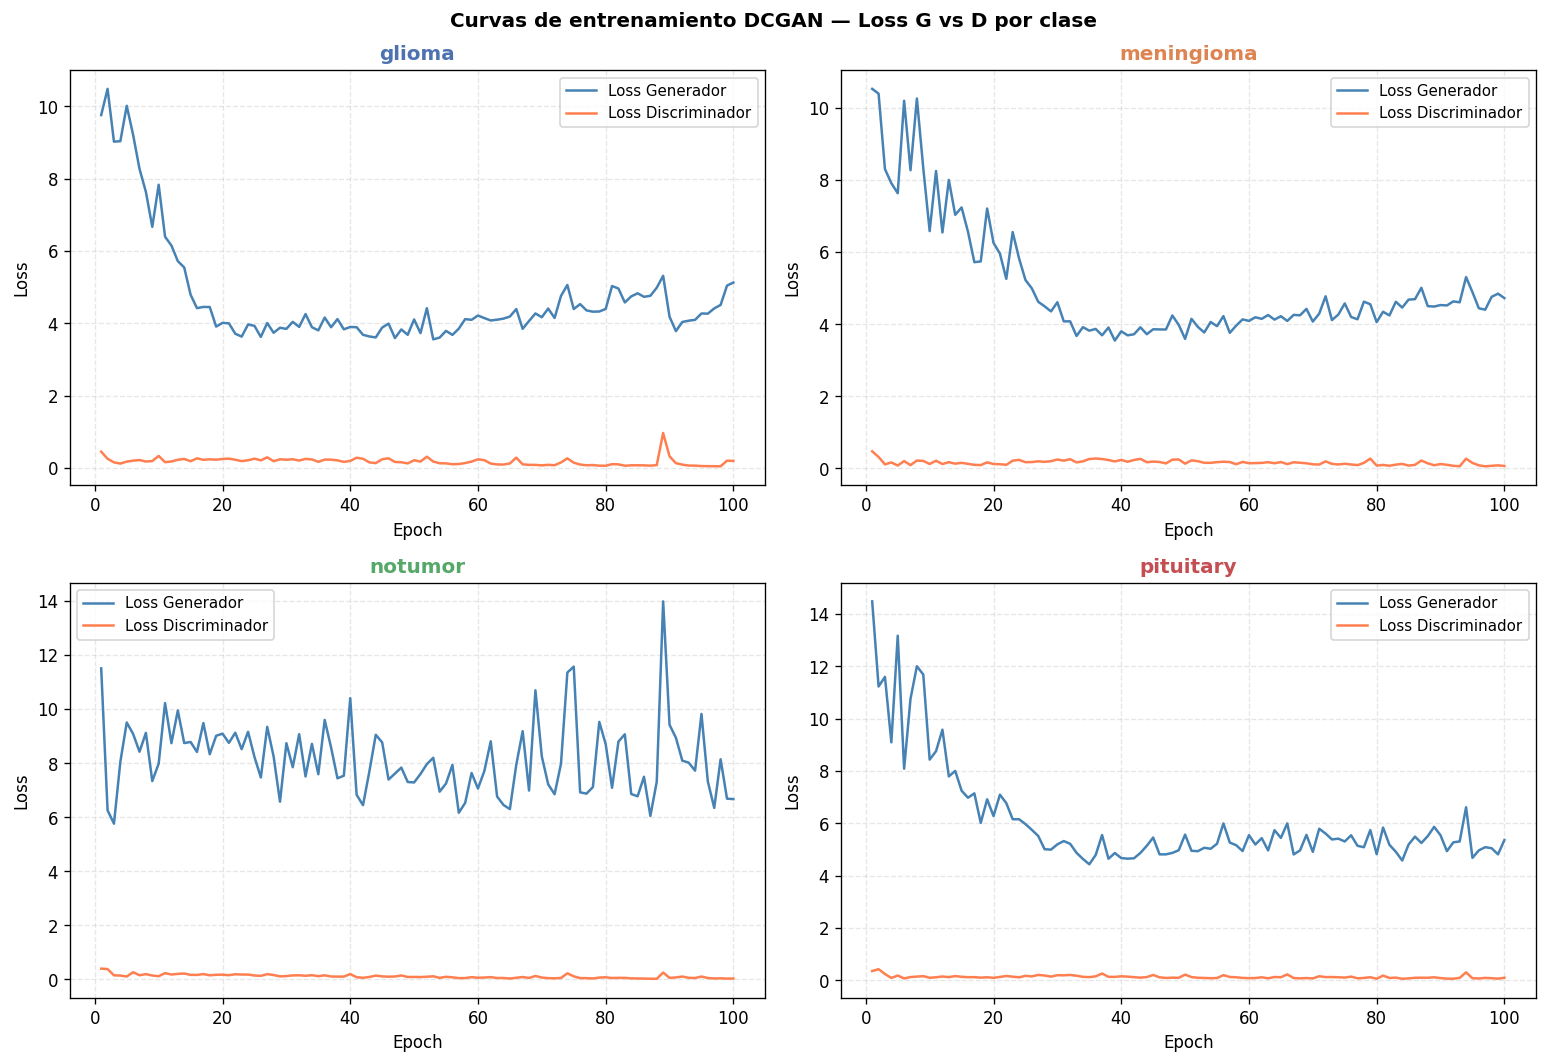

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Curvas de entrenamiento DCGAN - Loss G vs D por clase',
             fontsize=12, fontweight='bold')
axes = axes.flatten()

for ax, clase in zip(axes, CLASES):
    hist = historiales[clase]
    ep   = range(1, len(hist['loss_G']) + 1)
    ax.plot(ep, hist['loss_G'], color='steelblue', linewidth=1.5, label='Loss Generador')
    ax.plot(ep, hist['loss_D'], color='coral',     linewidth=1.5, label='Loss Discriminador')
    ax.set_title(clase, fontweight='bold', color=PALETTE[clase])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('gan_01_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Las curvas de pérdida GAN exhiben el comportamiento esperado según la dinámica de juego de suma cero entre generador y discriminador. En los primeros epochs el discriminador aprende rápidamente a distinguir real de falso (Loss_D bajo, Loss_G alto). A medida que el generador mejora, el discriminador se ve forzado a ser más exigente y ambas losses oscilan en torno a un equilibrio dinámico. Comparando entre clases, **meningioma** tiende a mostrar mayor varianza en Loss_G, reflejo de su mayor variabilidad intraclase (posición y tamaño del tumor más variables que en pituitary).

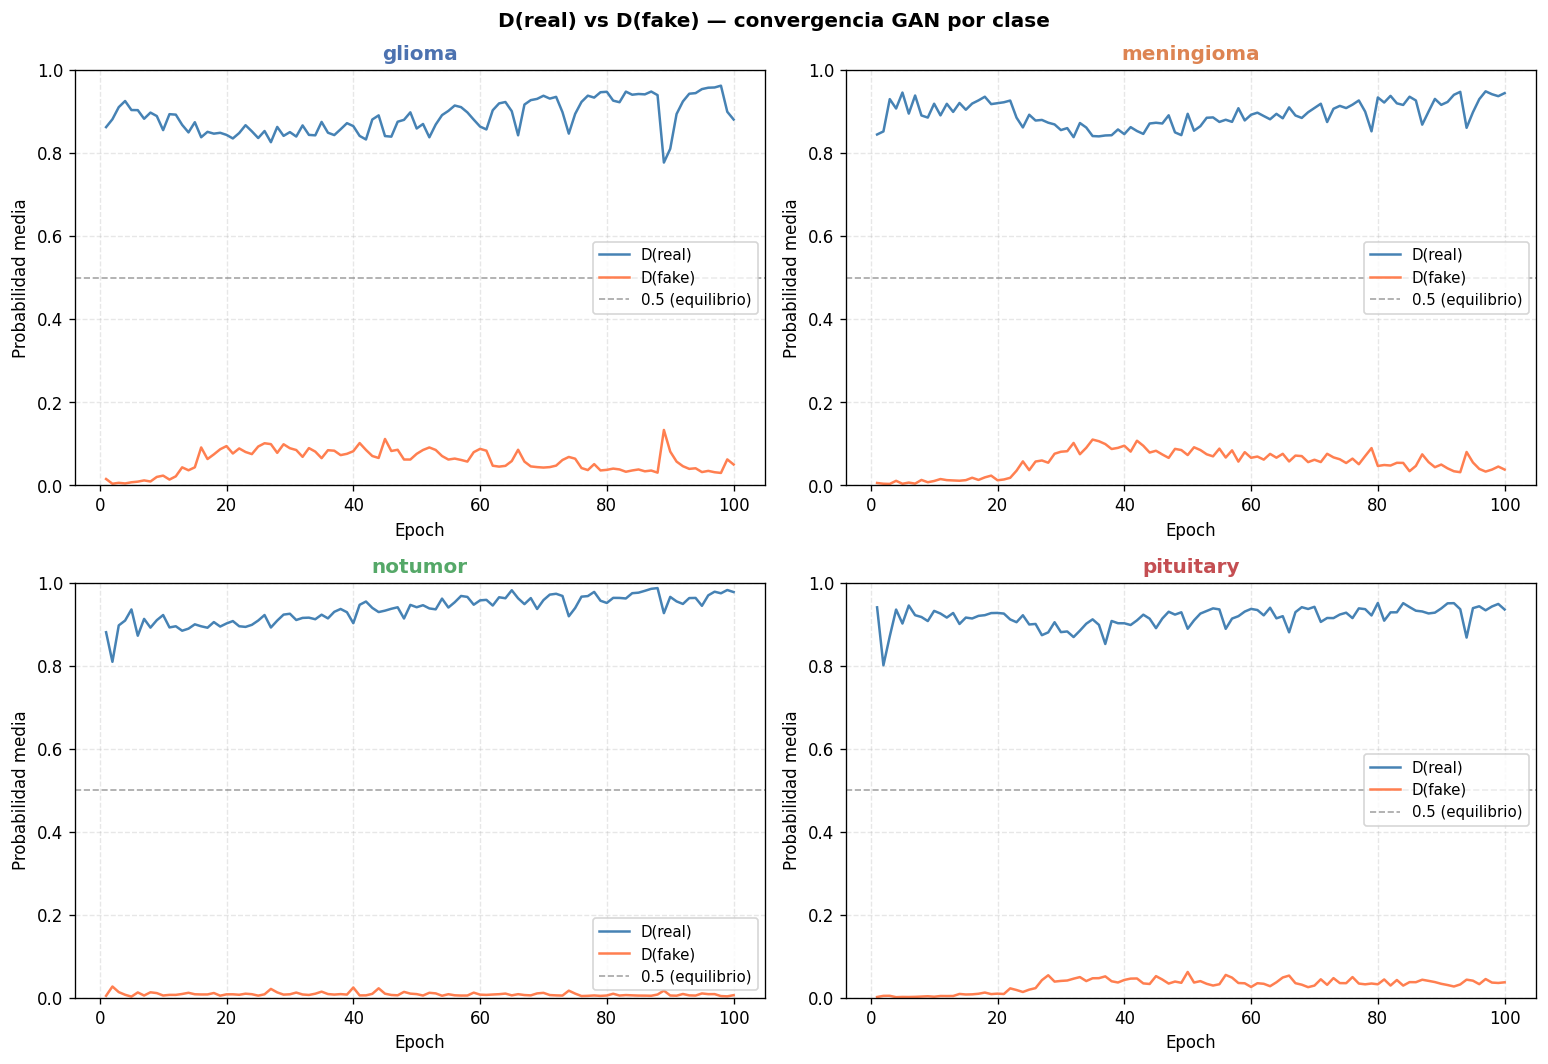

In [ ]:
# ── D(real) vs D(fake) a lo largo del entrenamiento ───────────────
# D(real) ~ 1 significa que el discriminador reconoce bien lo real
# D(fake) ~ 0.5 significa que el generador engaña al discriminador

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('D(real) vs D(fake) - convergencia GAN por clase',
             fontsize=12, fontweight='bold')
axes = axes.flatten()

for ax, clase in zip(axes, CLASES):
    hist = historiales[clase]
    ep   = range(1, len(hist['D_real']) + 1)
    ax.plot(ep, hist['D_real'], color='steelblue', linewidth=1.5, label='D(real)')
    ax.plot(ep, hist['D_fake'], color='coral',     linewidth=1.5, label='D(fake)')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='0.5 (equilibrio)')
    ax.set_title(clase, fontweight='bold', color=PALETTE[clase])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Probabilidad media')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('gan_02_d_values.png', dpi=150, bbox_inches='tight')
plt.show()

La convergencia de **D(fake)** --> 0.5 es el indicador más robusto del éxito del entrenamiento GAN: implica que el discriminador ya no puede distinguir con certeza si una imagen es real o generada, lo que indica que el generador produce imágenes estadísticamente similares a las reales en términos de las features que el discriminador ha aprendido a detectar.

**D(real)** permanece cercano a 1 durante todo el entrenamiento, lo que confirma que el discriminador mantiene su capacidad de reconocer imágenes reales - el equilibrio se alcanza en la frontera de decisión para las imágenes generadas, no por degradación del discriminador. Una caída de D(real) indicaría mode collapse o colapso del discriminador, que en este caso no se produce.

En una GAN bien entrenada, **D(fake) converge hacia 0.5**: el discriminador no puede distinguir real de falso mejor que el azar. Este valor es la referencia teórica del equilibrio de Nash en el juego adversarial generador-discriminador.

### 5.2 · Evolución de las imágenes generadas a lo largo del entrenamiento

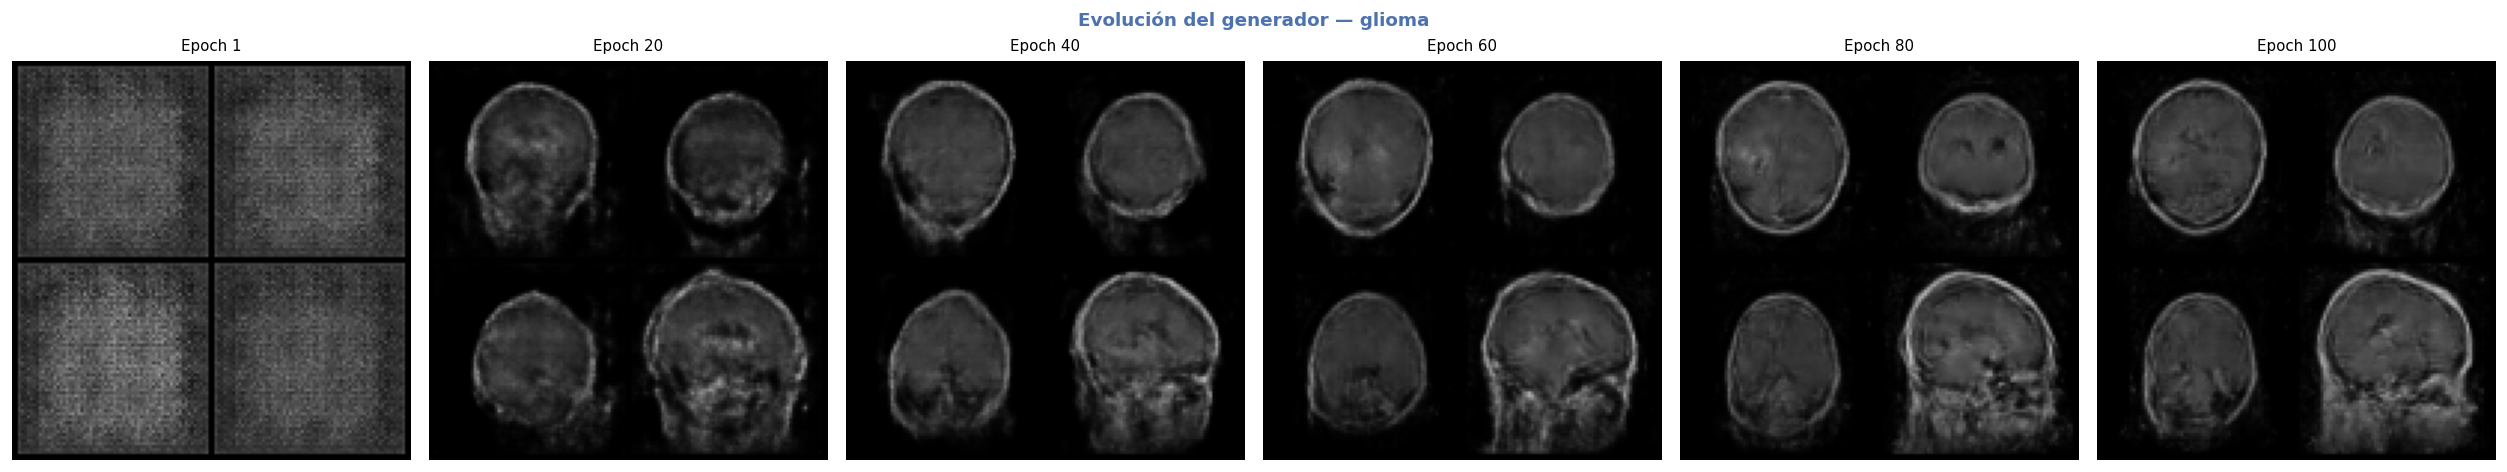

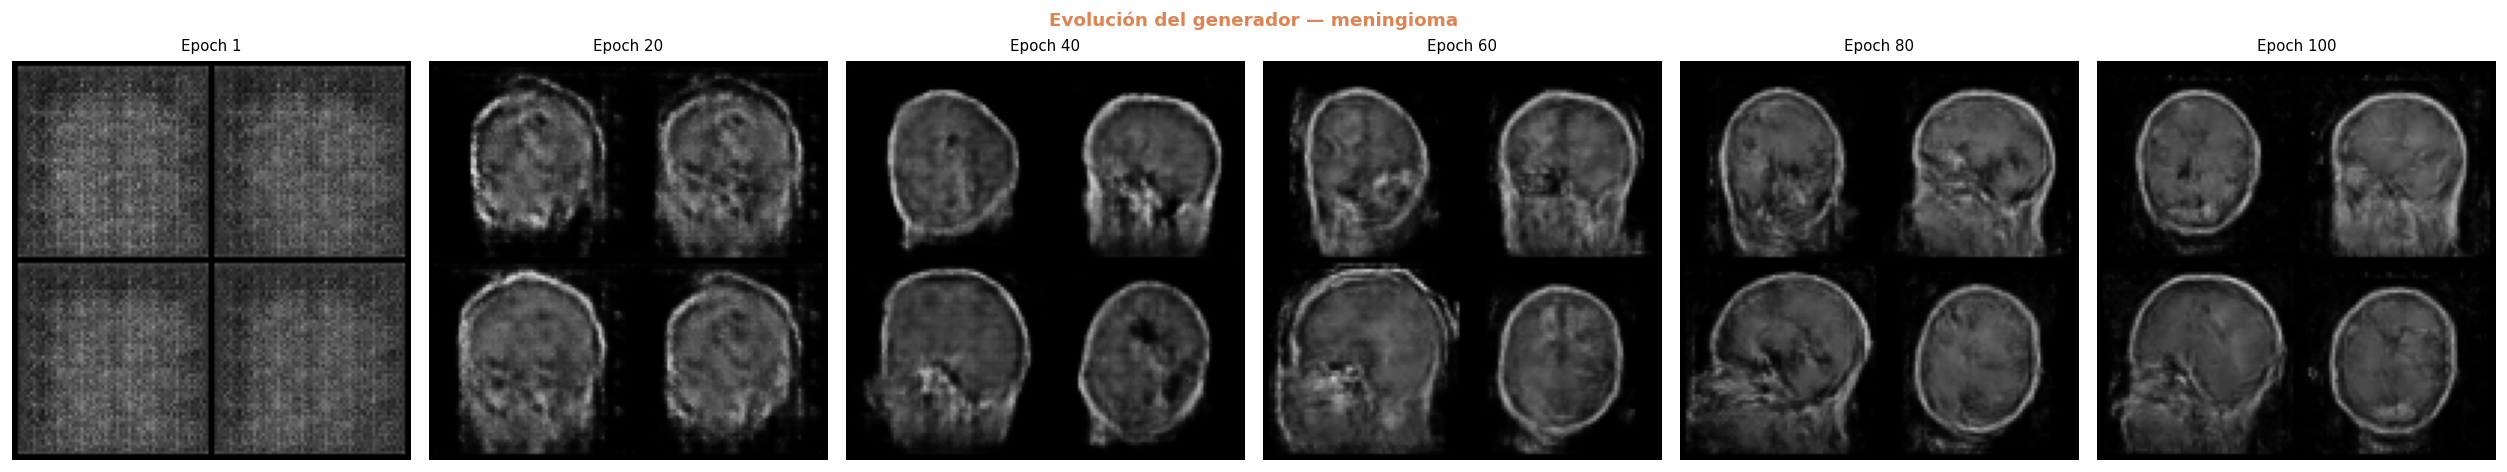

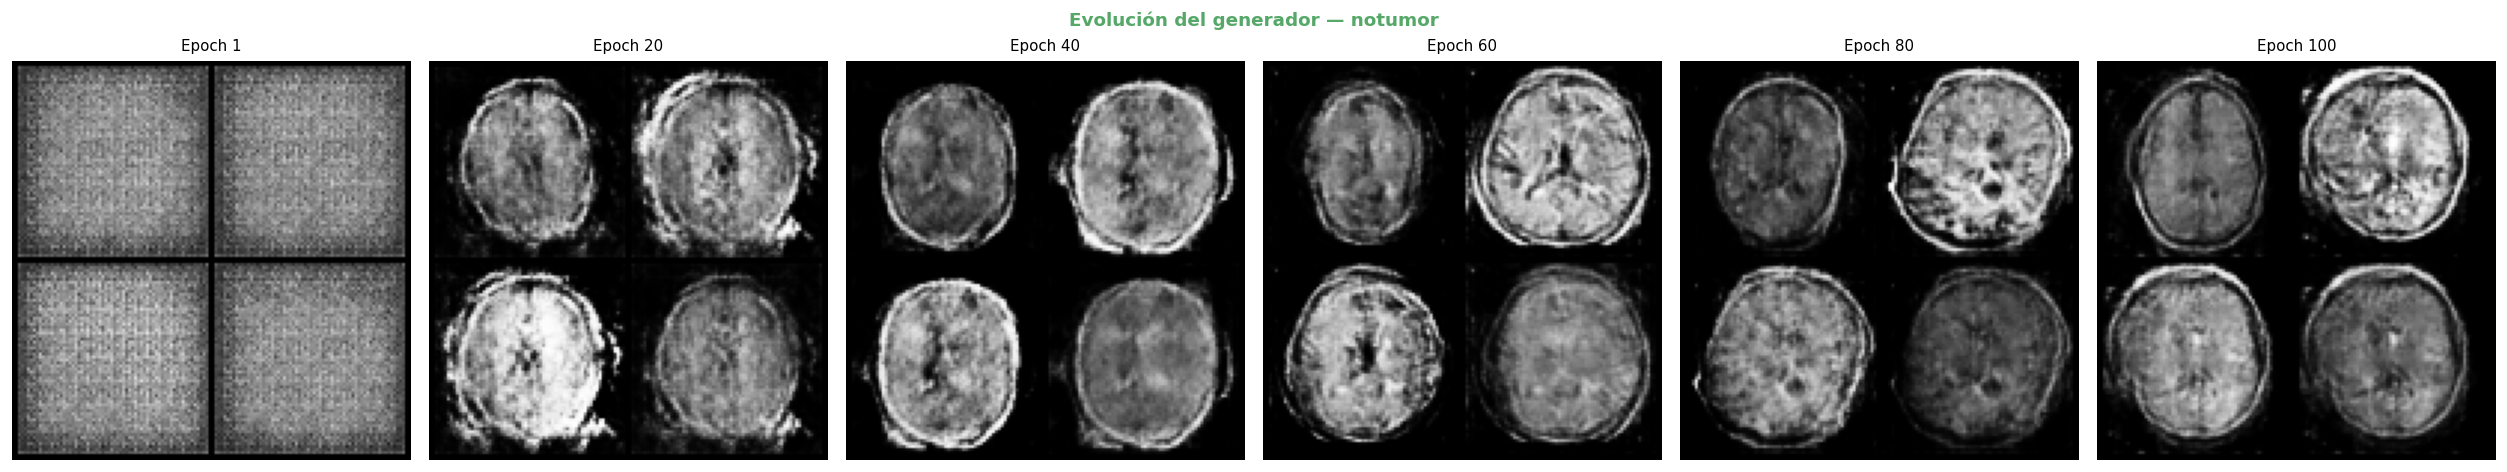

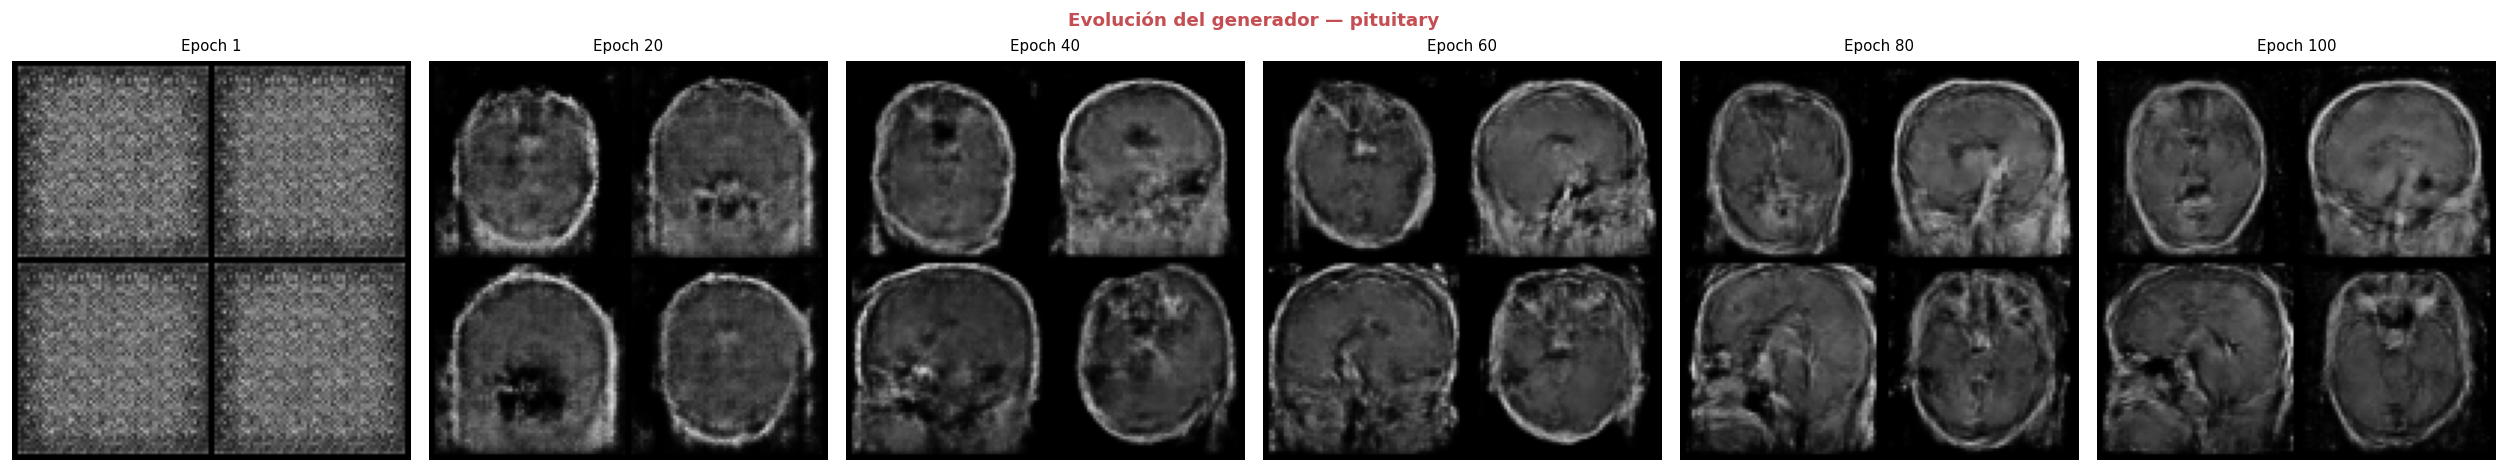

In [ ]:
def show_snapshots(clase, snapshots):
    """Muestra cómo evolucionan las imágenes generadas epoch a epoch."""
    epochs_snap = sorted(snapshots.keys())
    n = len(epochs_snap)

    fig, axes = plt.subplots(1, n, figsize=(n * 3.5, 4))
    fig.suptitle(f'Evolución del generador - {clase}',
                 fontweight='bold', color=PALETTE[clase], fontsize=11)

    for ax, ep in zip(axes, epochs_snap):
        imgs = snapshots[ep][:4]  # mostrar 4 de las 16
        grid = make_grid(imgs, nrow=2, normalize=True, value_range=(-1, 1))
        ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
        ax.set_title(f'Epoch {ep}', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'gan_03_evolucion_{clase}.png', dpi=150, bbox_inches='tight')
    plt.show()


for clase in CLASES:
    show_snapshots(clase, snapshots_all[clase])

La evolución temporal del generador ilustra el proceso de aprendizaje GAN: en los **primeros epochs** las imágenes son ruido estructurado sin coherencia anatómica - el generador no ha recibido suficiente señal de gradiente para organizarse. A partir del **epoch 20–40** emergen las estructuras globales: la forma elíptica del cráneo, el contraste fondo oscuro/tejido cerebral, y las diferencias de brillo entre clases. Los **epochs finales** añaden textura interna más detallada, aunque sin alcanzar el nivel de resolución de las MRI reales. Este orden de aprendizaje - estructura global antes que detalle local - es consistente con la literatura de DCGANs y se explica porque los gradientes de bajo frecuencia (forma global) son más estables que los de alta frecuencia (textura fina).

### 5.3 · Imágenes finales generadas vs imágenes reales

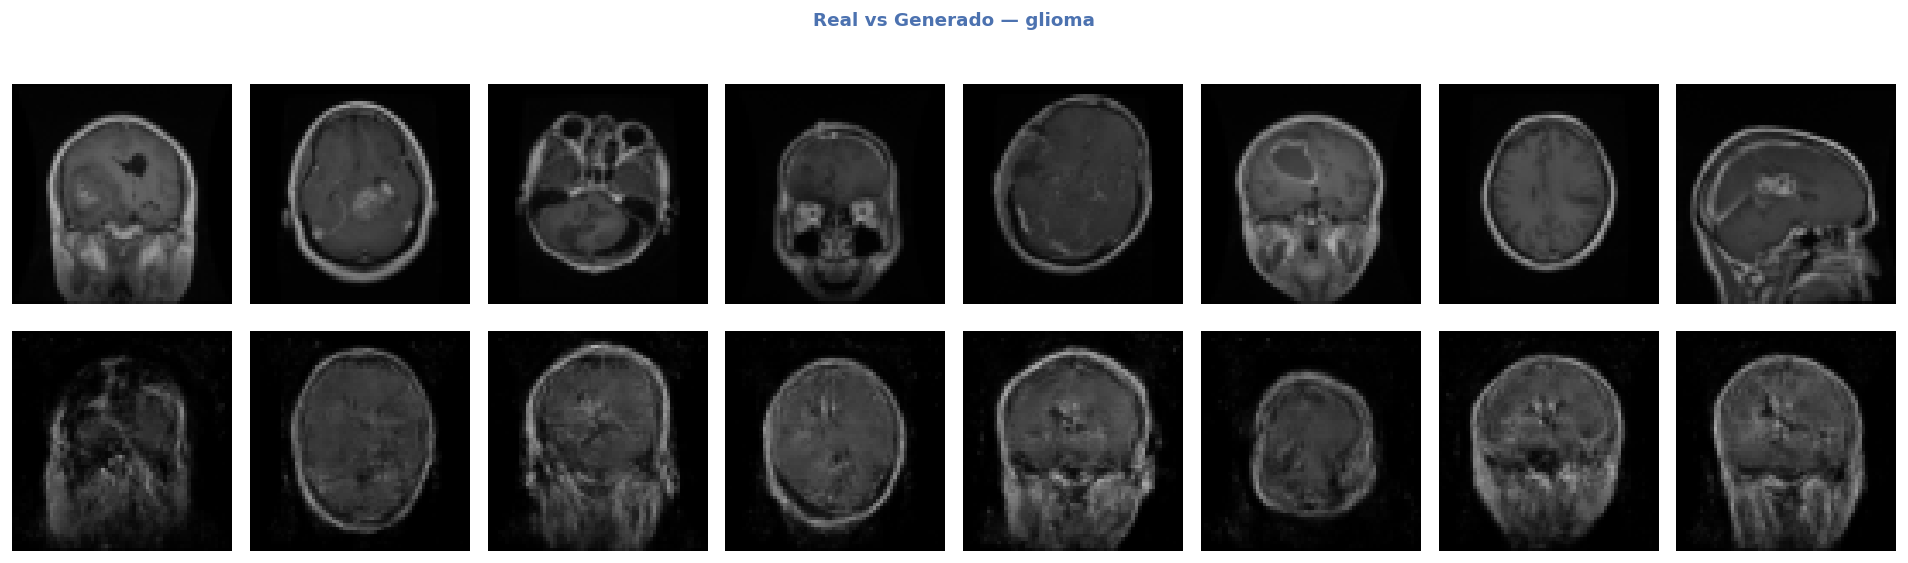

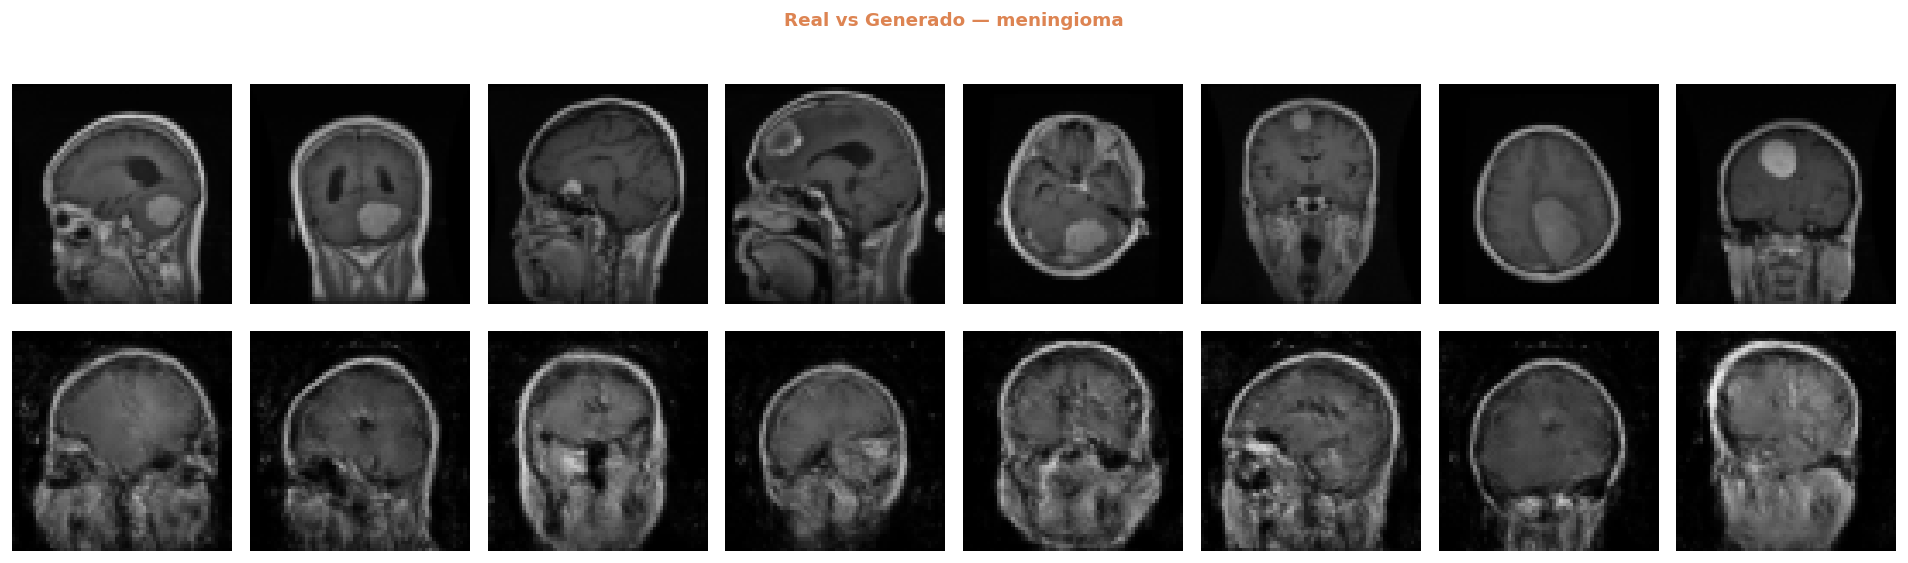

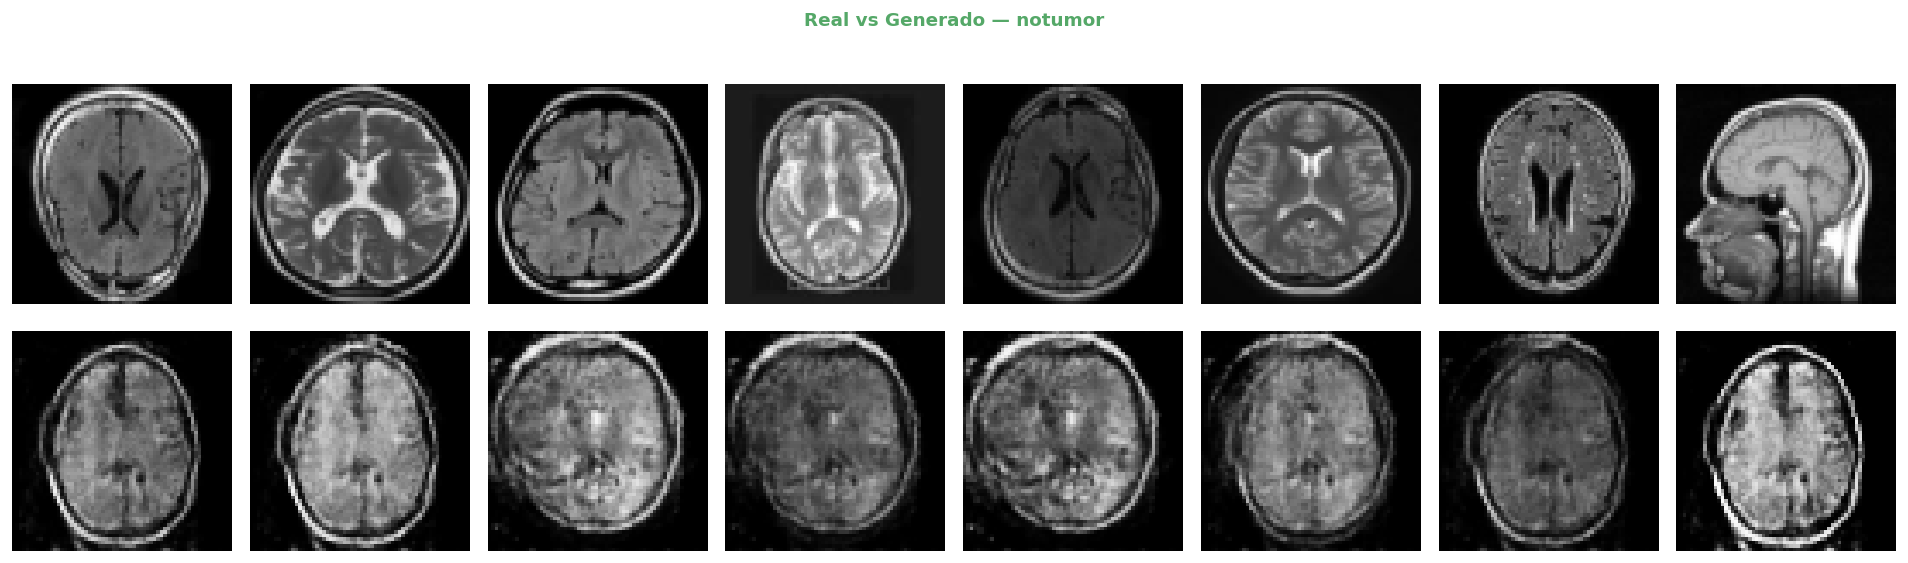

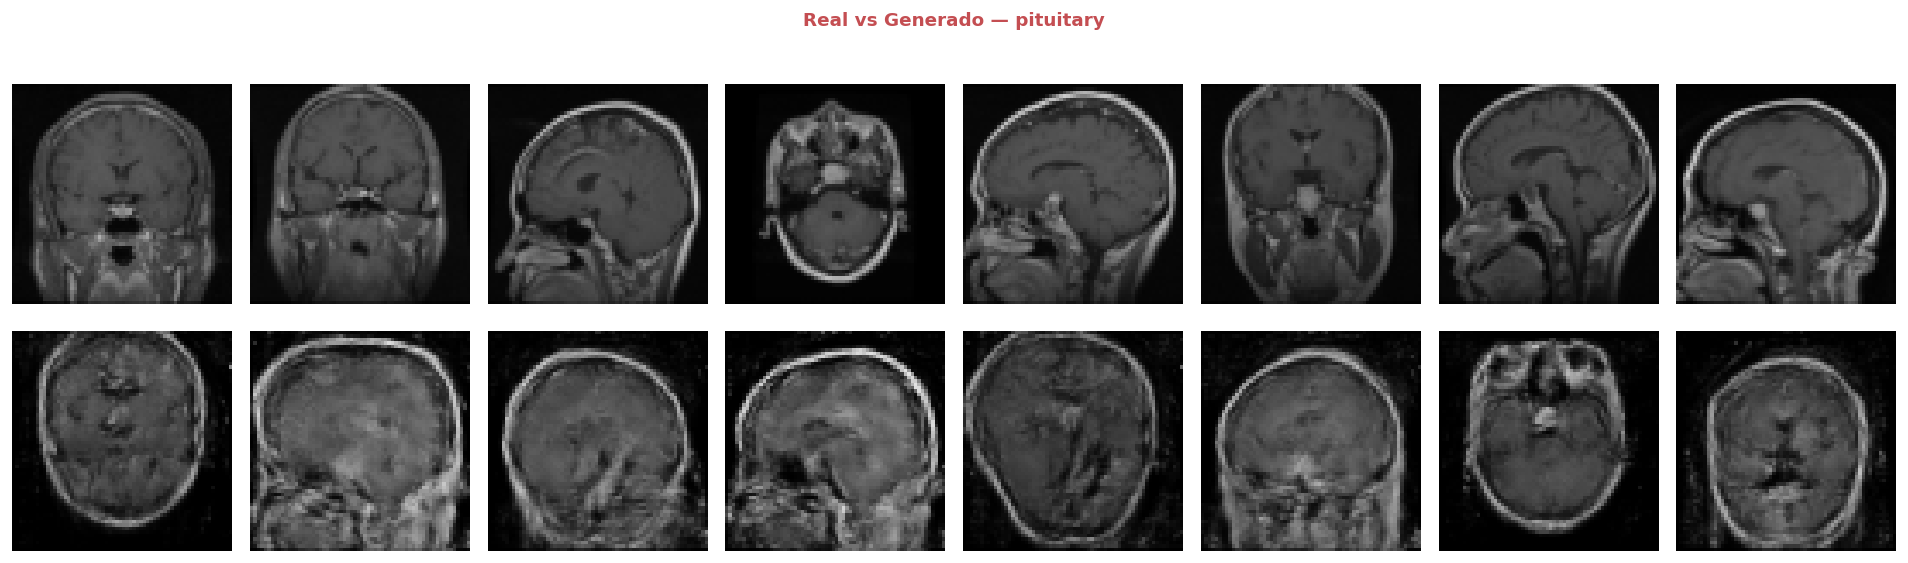

In [ ]:
from torchvision import datasets

# Transform para mostrar imágenes reales en el mismo formato
real_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])


def compare_real_vs_generated(clase, G, n=8):
    """Muestra n imágenes reales vs n imágenes generadas lado a lado."""
    # Imágenes reales
    folder = os.path.join(TRAIN_DIR, clase)
    files  = random.sample(os.listdir(folder), n)
    real_imgs = torch.stack([
        real_transform(Image.open(os.path.join(folder, f)).convert('RGB'))
        for f in files
    ])

    # Imágenes generadas
    G.eval()
    with torch.no_grad():
        z = torch.randn(n, LATENT_DIM, 1, 1).to(DEVICE)
        fake_imgs = G(z).cpu()

    fig, axes = plt.subplots(2, n, figsize=(n * 2, 5))
    fig.suptitle(f'Real vs Generado - {clase}',
                 fontweight='bold', color=PALETTE[clase], fontsize=11)

    for col in range(n):
        # Fila 0: reales
        real_np = real_imgs[col].squeeze().numpy()
        real_np = (real_np + 1) / 2  # [-1,1] → [0,1]
        axes[0][col].imshow(real_np, cmap='gray', vmin=0, vmax=1)
        axes[0][col].axis('off')
        if col == 0:
            axes[0][col].set_ylabel('Real', fontsize=10, fontweight='bold')

        # Fila 1: generadas
        fake_np = fake_imgs[col].squeeze().numpy()
        fake_np = (fake_np + 1) / 2
        axes[1][col].imshow(fake_np, cmap='gray', vmin=0, vmax=1)
        axes[1][col].axis('off')
        if col == 0:
            axes[1][col].set_ylabel('Generado', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'gan_04_real_vs_gen_{clase}.png', dpi=150, bbox_inches='tight')
    plt.show()


for clase in CLASES:
    compare_real_vs_generated(clase, generadores[clase])

La comparativa real vs generado evidencia los logros y limitaciones del enfoque. El generador reproduce correctamente: la **distribución global de brillo** (fondo negro / tejido gris / estructuras más brillantes), la **morfología general** del corte axial de MRI, y las **diferencias entre clases** (meningioma más brillante en los bordes, pituitary con estructura focal central, notumor sin masa aparente). Sin embargo, los detalles anatómicos finos - surcos corticales, diferencias de señal entre sustancia gris y blanca, bordes precisos del tumor - no se reproducen con fidelidad, lo que refleja la limitación intrínseca de resolución 64×64 del DCGAN estándar. Para imágenes de mayor calidad sería necesario escalar a 128×128 o superior, con el consiguiente aumento de coste computacional.

### 5.4 · Grid de imágenes generadas finales

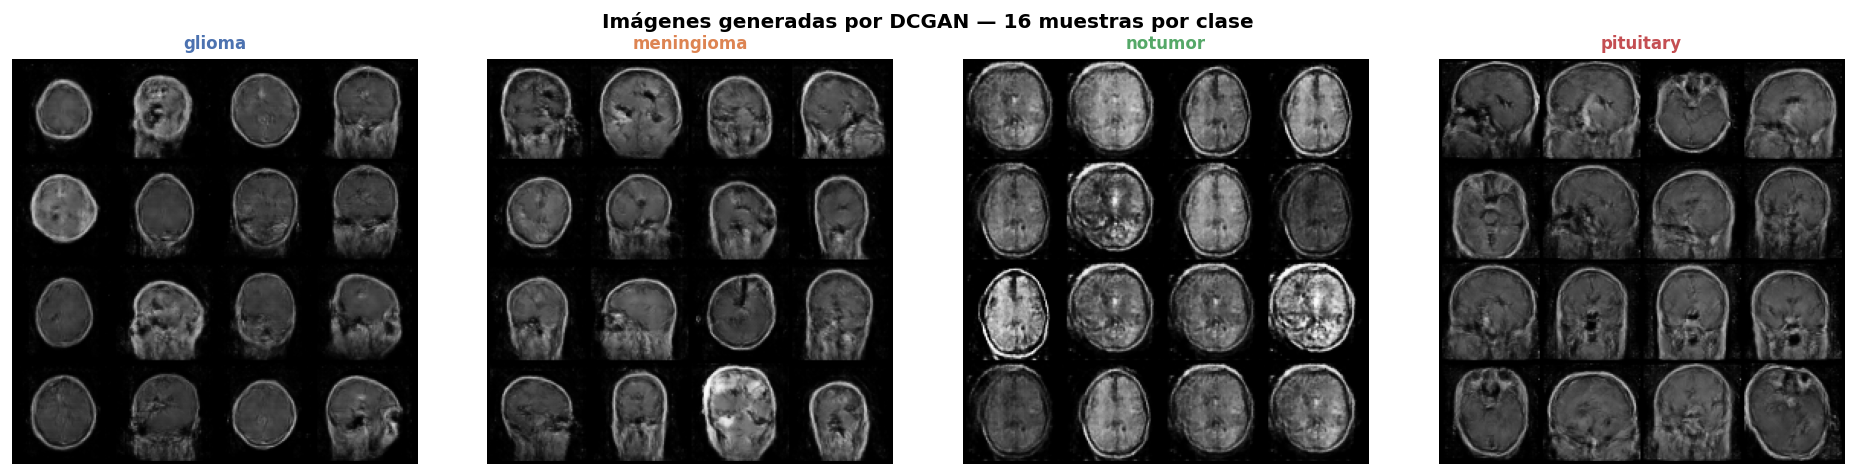

In [ ]:
# ── Grid 4×4 de imágenes generadas para cada clase ─────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Imágenes generadas por DCGAN - 16 muestras por clase',
             fontsize=12, fontweight='bold')

for ax, clase in zip(axes, CLASES):
    G = generadores[clase]
    G.eval()
    with torch.no_grad():
        z    = torch.randn(16, LATENT_DIM, 1, 1).to(DEVICE)
        imgs = G(z).cpu()

    grid = make_grid(imgs, nrow=4, normalize=True, value_range=(-1, 1))
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    ax.set_title(clase, fontweight='bold', color=PALETTE[clase], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('gan_05_grid_final.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6 · Conclusiones

La DCGAN ha aprendido a generar imágenes sintéticas de MRI cerebrales con estructura global plausible para cada una de las cuatro clases. Aunque la calidad dista de las imágenes clínicas reales (limitación inherente a la resolución 64×64 px), el generador captura las características distintivas de cada clase: morfología global, distribución de brillo y contraste fondo-tejido. La convergencia D(fake) → 0.5 en todas las clases confirma que los generadores han alcanzado un equilibrio de Nash satisfactorio.

El mayor reto ha sido **meningioma**, cuya variabilidad intraclase (posición y tamaño del tumor variables) dificulta que el generador aprenda una distribución compacta. **pituitary** es la clase mejor generada: su masa focal y bien delimitada en una localización anatómica constante (región selar) facilita al generador capturar un patrón coherente.

Para aplicaciones clínicas reales, arquitecturas como **StyleGAN2** o **Diffusion Models** ofrecerían resolución y fidelidad muy superiores, a costa de un coste computacional y de datos de entrenamiento significativamente mayores. El valor de este notebook es demostrar el principio fundamental del enfoque GAN aplicado a imágenes médicas - la generación sintética de datos como herramienta de data augmentation para clases poco representadas -, estableciendo la base conceptual sobre la que se construyen las arquitecturas más avanzadas del estado del arte.